# **Projeto da Disciplina**
## **Engenharia de Machine Learning - 25E1_3**

------------------------------------

> Fonte da base de dados
> <br>
> [Kaggle - Kobe Bryant Shot Selection](https://www.kaggle.com/c/kobe-bryant-shot-selection/data)
> <br>
> [Dados de desenvolvimento e produção](https://github.com/tciodaro/eng_ml/tree/main/data)


> Importação das bibliotecas necessárias para execução desse notebook

### **Questão 1)**
#### A solução criada nesse projeto deve ser disponibilizada em repositório git e disponibilizada em servidor de repositórios (Github (recomendado), Bitbucket ou Gitlab). O projeto deve obedecer o Framework TDSP da Microsoft (estrutura de arquivos, arquivo requirements.txt e arquivo README - com as respostas pedidas nesse projeto, além de outras informações pertinentes). Todos os artefatos produzidos deverão conter informações referentes a esse projeto (não serão aceitos documentos vazios ou fora de contexto). Escreva o link para seu repositório. 


>Resposta:
> <br>
> Link do GitHub: [https://github.com/ianmsouza/xxxxxxxxx](https://github.com/ianmsouza/xxxxxxxxxx)
> <br><br>
> 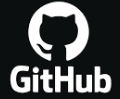

### **Questão 2)**
#### Iremos desenvolver um preditor de arremessos usando duas abordagens (regressão e classificação) para prever se o "Black Mamba" (apelido de Kobe) acertou ou errou a cesta.<br><br>Baixe os dados de desenvolvimento e produção [aqui](https://github.com/tciodaro/eng_ml/tree/main/data) (datasets: dataset_kobe_dev.parquet e dataset_kobe_prod.parquet). Salve-os numa pasta /data/raw na raiz do seu repositório.<br><br>Para começar o desenvolvimento, desenhe um diagrama que demonstra todas as etapas necessárias para esse projeto, desde a aquisição de dados, passando pela criação dos modelos, indo até a operação do modelo.

>Resposta:
><br><br>
> **1️⃣ Aquisição de Dados**
> - Coleta dos dados brutos fornecidos (`data.csv`, `dataset_kobe_dev.parquet`, etc.).
> - Armazenamento na pasta `/Data/Raw`.
>
> **2️⃣ Pré-processamento dos Dados**
> - Remoção de valores ausentes.
> - Seleção das colunas relevantes: `lat`, `lng`, `minutes_remaining`, etc.
> - Salvamento dos dados tratados em `/Data/Processed`.
>
> **3️⃣ Separação em Treino/Teste**
> - Separação estratificada dos dados (80% treino, 20% teste).
> - Bases armazenadas em `/Data/Processed/base_train.parquet` e `base_test.parquet`.
>
> **4️⃣ Treinamento dos Modelos**
> - Modelos: **Regressão Logística e Árvore de Decisão**.
> - Ferramentas: **PyCaret, MLFlow** para rastreamento de experimentos.
>
> **5️⃣ Avaliação dos Modelos**
> - Cálculo de métricas: **Log-Loss e F1-score**.
> - Comparação dos modelos para seleção do melhor.
>
> **6️⃣ Deploy/Operacionalização**
> - O modelo escolhido é armazenado e carregado para previsões em produção.
> - Implementação via **MLFlow, API Flask ou Streamlit**.
>
> **7️⃣ Monitoramento do Modelo**
> - Registro contínuo das métricas em produção.
> - Avaliação de performance via **MLFlow e Streamlit**.
>
> **8️⃣ Atualização do Modelo**
> - Estratégias:
>   - **Reativa**: Atualiza quando a performance do modelo cai.
>   - **Preditiva**: Prevê mudanças e ajusta o modelo antes da degradação.
>
> **Conclusão**
> A estrutura TDSP garante um fluxo bem definido para o desenvolvimento e operacionalização do modelo.
> Esse processo facilita a rastreabilidade, a colaboração e a atualização contínua dos modelos de Machine Learning.


### **Questão 3)**
#### Como as ferramentas Streamlit, MLFlow, PyCaret e Scikit-Learn auxiliam na construção dos pipelines descritos anteriormente? A resposta deve abranger os seguintes aspectos: <br><br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Rastreamento de experimentos;<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Funções de treinamento;<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;c. Monitoramento da saúde do modelo;<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;d. Atualização de modelo;<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;e. Provisionamento (Deployment).

> Resposta:
><br><br>
> A construção do pipeline de Machine Learning segue a estrutura definida no Framework TDSP, permitindo que cada ferramenta desempenhe um papel específico dentro do fluxo de trabalho.
> <br>
> A seguir, uma explicação de como Streamlit, MLFlow, PyCaret e Scikit-Learn auxiliam em cada uma das fases do projeto:
> <br><br>
> **a. Rastreamento de Experimentos**
> <br>
> 🛠️ Ferramenta principal: MLFlow
> - O MLFlow permite registrar métricas, parâmetros e artefatos de cada experimento.
> - Isso facilita a comparação de diferentes modelos e versões treinadas.
> - No nosso pipeline, cada modelo será registrado no MLFlow, garantindo rastreabilidade.
> 
> Exemplo de uso no código:
>


In [3]:
import mlflow

mlflow.start_run(run_name="Treinamento_Regressao_Logistica")
mlflow.log_param("algoritmo", "Regressão Logística")
mlflow.log_metric("log_loss", 0.245)
mlflow.end_run()


> 🛠️ PyCaret também auxilia
> <br>
> - O PyCaret já possui integração nativa com o MLFlow, facilitando o log automático dos experimentos.
> - Isso simplifica o rastreamento sem precisar adicionar código extra.
> 
> **b. Funções de Treinamento**
> <br>🛠️ Ferramentas principais: PyCaret e Scikit-Learn
> - PyCaret automatiza o processo de treinamento, permitindo testar múltiplos modelos rapidamente.
> - Scikit-Learn fornece as bibliotecas base para treinar modelos, como Regressão Logística e Árvore de Decisão.
> - No nosso pipeline, utilizamos PyCaret para selecionar e avaliar os melhores modelos.
> 
> Exemplo de uso no código:
>

In [ ]:
from pycaret.classification import setup, compare_models

setup(data=df_train, target="shot_made_flag")
melhor_modelo = compare_models()


> - O MLFlow pode ser usado para registrar os modelos treinados, salvando artefatos para deploy futuro.
>
> **c. Monitoramento da Saúde do Modelo**
> <br>🛠️ Ferramentas principais: MLFlow e Streamlit
> - MLFlow armazena logs das execuções dos modelos em produção, possibilitando a análise de degradação do desempenho.
> - Streamlit pode ser usado para criar dashboards interativos e monitorar métricas como Log Loss e F1-score.
> 
> Exemplo de código para exibir métricas no Streamlit:
>


In [ ]:
import streamlit as st
import mlflow

# Recupera a última execução no MLFlow
experiment = mlflow.get_experiment_by_name("Treinamento")
run = mlflow.search_runs(experiment.experiment_id).iloc[0]

# Exibir métricas no Streamlit
st.title("Monitoramento do Modelo")
st.metric(label="Log Loss", value=run["metrics.log_loss"])
st.metric(label="F1 Score", value=run["metrics.f1_score"])


> **d. Atualização do Modelo**
> <br>🛠️ Ferramentas principais: MLFlow e PyCaret
> - O modelo pode ser atualizado através de estratégias reativas e preditivas.
> - O MLFlow permite versionar diferentes treinamentos, facilitando a troca do modelo sempre que houver degradação.
> - O PyCaret facilita o re-treinamento do modelo de forma simples:

In [ ]:
from pycaret.classification import tune_model

# Ajusta os hiperparâmetros do modelo automaticamente
melhor_modelo_ajustado = tune_model(melhor_modelo)


> - Essa abordagem facilita a implantação de novos modelos sem impactar a operação.
>
> **e. Provisionamento (Deployment)**
> <br>🛠️ Ferramentas principais: MLFlow e Streamlit
> - O MLFlow Models permite exportar e servir modelos automaticamente como uma API:

In [ ]:
bash
mlflow models serve -m ./mlruns/1/best_model -p 5000


> - Streamlit pode ser usado para criar uma interface gráfica, permitindo que usuários façam previsões diretamente pelo navegador.
>
> Exemplo de código para criar um dashboard interativo:


In [ ]:
import streamlit as st
import pickle

modelo = pickle.load(open("modelo.pkl", "rb"))

st.title("Preditor de Arremessos do Kobe Bryant")
shot_distance = st.slider("Distância do arremesso", 0, 30, 15)
prediction = modelo.predict([[shot_distance]])

st.write("Probabilidade de acerto:", prediction[0])


> Isso facilita a interação com o modelo sem precisar de habilidades técnicas.
>
> **Conclusão Final**
>
> Cada ferramenta desempenha um papel fundamental no pipeline de Machine Learning:


| **Ferramenta**    | **Função Principal** |
|-------------------|-----------------------------------------------|
| **MLFlow**       | Rastreamento de experimentos, versionamento de modelos e monitoramento |
| **PyCaret**      | Automação de treinamento e comparação de modelos |
| **Scikit-Learn** | Implementação dos modelos clássicos de Machine Learning |
| **Streamlit**    | Construção de dashboards para visualização e deploy interativo |


> Com essa abordagem, garantimos um pipeline eficiente, rastreável e totalmente operacional, atendendo às exigências do TDSP e permitindo um fluxo contínuo de treinamento, avaliação, deploy e monitoramento. 